<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-resnet/blob/main/MSE_RESNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D
from keras.layers import Add, Input
from keras.models import Model

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "//content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


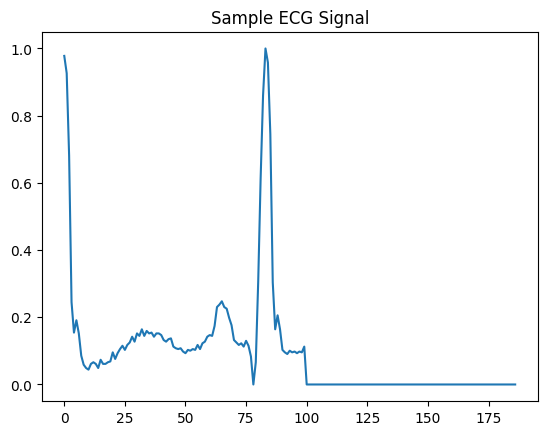

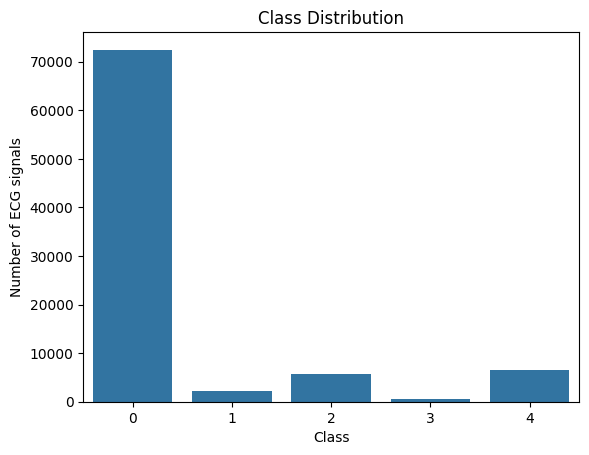

0
0


In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
y_res_sparse = y_res.copy()   # save 1D labels BEFORE one-hot

# Then convert for training
y_res = to_categorical(y_res, 5)

In [ ]:
y_res_sparse = y_res
y_test_sparse = y_test

X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [ ]:
def resnet_block(x, filters, stride=1):
    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x

In [ ]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(16,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,32)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64,activation='relu')(x)
    outputs = Dense(5,activation='softmax')(x)

    model = Model(inputs,outputs)

    model.compile(
        optimizer='adam',
        loss='mse',   # ✅ MSE LOSS HERE
        metrics=['accuracy']
    )

    return model

In [ ]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

model = resnet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=5,
    batch_size=128
)

Epoch 1/5
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - accuracy: 0.1988 - loss: 5.2361 - val_accuracy: 0.2497 - val_loss: 5.2559
Epoch 2/5
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.2000 - loss: 5.2360 - val_accuracy: 0.1970 - val_loss: 5.2559
Epoch 3/5
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.1986 - loss: 5.2360 - val_accuracy: 0.2050 - val_loss: 5.2559
Epoch 4/5
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.1971 - loss: 5.2360 - val_accuracy: 0.1904 - val_loss: 5.2559
Epoch 5/5
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.1980 - loss: 5.2360 - val_accuracy: 0.1932 - val_loss: 5.2559


In [ ]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = y_val_final

mcc = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
Validation MCC: -0.014232908644581481


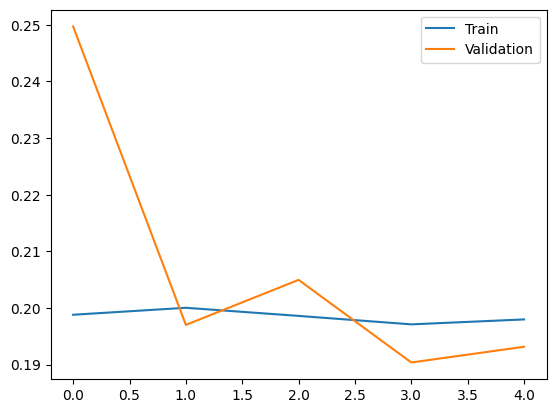

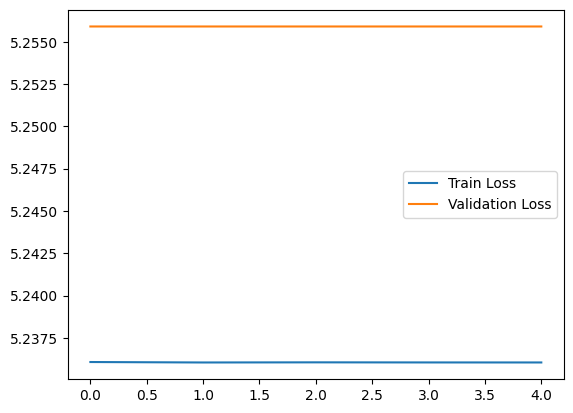

In [ ]:
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test   # ✅ no argmax

print(classification_report(y_true, y_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7137 - loss: 1.3823
Test Accuracy: 0.713731050491333
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.85     18118
         1.0       0.02      0.05      0.02       556
         2.0       0.10      0.03      0.04      1448
         3.0       0.01      0.02      0.01       162
         4.0       0.11      0.07      0.08      1608

    accuracy                           0.71     21892
   macro avg       0.22      0.20      0.20     21892
weighted avg       0.71      0.71      0.71     21892



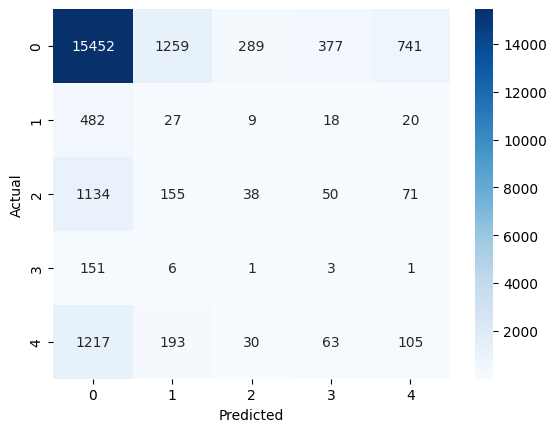

In [ ]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res_sparse)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]

    y_tr = tf.keras.utils.to_categorical(y_res_sparse.iloc[train_idx], 5)
    y_va = tf.keras.utils.to_categorical(y_res_sparse.iloc[val_idx], 5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.9353 - loss: 0.0195
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9688 - loss: 0.0097
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9782 - loss: 0.0068
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9829 - loss: 0.0054
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9860 - loss: 0.0044
Fold 1 Accuracy: 0.9779

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.9400 - loss: 0.0183
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9727 - loss: 0.0085
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9809 - loss: 0.0059
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9856 - loss: 0.0045
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9881 - loss: 0.0038
Fold 2 Accuracy: 0.9832

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms